# 珊瑚礁保护配置与微塑料暴露：实际数据研究 Demo

**Reef conservation and microplastic exposure — a real-input scientific notebook**

本Notebook以29,746个真实珊瑚礁网格为输入，逐步完成等面积优先区选择、暴露指标、1,000次联合气候模型/空间块bootstrap、Table S5重算及图件输出。

数据和算法来自2026-09-06确认的修复版保护配置主线。这里复现从**已归档网格派生输入到保护配置结果**的完整模块，原海洋模式和MaxEnt训练有额外输入需求。

使用方法：在仓库根目录创建并激活Python环境，安装`requirements.txt`，启动`jupyter lab`，打开本文件后选择 **Run → Run All Cells**。源文件保持只读；新结果写入`outputs/notebook_demo/`。

## 1. 环境与参数

默认参数保留原分析的三个SSP、三个气候成员、四个区域、5°空间块、随机种子20260804和1,000次重复。区域存在重叠，不能把全球与区域结果求和。

修改重复次数或随机种子可以运行新的分析，但会被标记为自定义/缩短运行，不再声称复现完整冻结区间。

In [1]:
from pathlib import Path
import hashlib
import json
import platform
import time

import numpy as np
import pandas as pd
from IPython.display import Image, display

from analysis.modules.conservation_demo.code import conservation_core as core
from analysis.modules.conservation_demo.code.run_all import (
    load_inputs, compare_frames, compact_table, export_priorities, render_figures, sha
)

ROOT = Path.cwd()
MODULE = ROOT / "analysis/modules/conservation_demo"
if not (MODULE / "provenance.json").is_file():
    raise RuntimeError("Open this notebook from the repository root.")

INPUT_FILE = MODULE / "data/reef_cells.csv.gz"
OUTPUT = ROOT / "outputs/notebook_demo"
N_BOOTSTRAP = 1000
RANDOM_SEED = 20260804
if N_BOOTSTRAP < 1 or RANDOM_SEED < 0:
    raise ValueError("Replicates must be positive and seed must be nonnegative.")
OUTPUT.mkdir(parents=True, exist_ok=True)
started = time.perf_counter()

pd.set_option("display.max_columns", 12)
pd.set_option("display.max_rows", 15)
display(pd.DataFrame({"package": ["Python", "NumPy", "pandas"],
                      "version": [platform.python_version(), np.__version__, pd.__version__]}))

,package,version
0,Python,3.12.10
1,NumPy,2.3.5
2,pandas,2.3.3


## 2. 来源核验与实际输入

输入包括面积、既有MPA比例、未来MPEI及模型支持掩膜。所有原网格行和顺序保留；只去除了本计算不使用的WKB几何和分量字段。浮点CSV使用17位有效数字，并已逐列验证与原Parquet精确相等。

先核对来源哈希和物理字段。`reference/`中的冻结输出只用于计算后的核对，不参与优先区选择或抽样。

In [2]:
manifest = json.loads((MODULE / "provenance.json").read_text(encoding="utf-8"))
hash_records = []
for record in manifest["files"]:
    current_hash = sha(ROOT / record["file"])
    if current_hash != record["sha256"]:
        raise ValueError(f"Source hash mismatch: {record['file']}")
    hash_records.append({"file": record["file"], "role": record["role"], "SHA-256": "matched"})
original_input = sha(INPUT_FILE) == next(
    record["sha256"] for record in manifest["files"] if record["role"] == "runtime_input"
)

reef, member_masks = load_inputs(INPUT_FILE)
print(f"Actual input: {len(reef):,} cells, {len(reef.columns)} fields")
print(f"Climate scenarios: {len(core.SCENARIOS)}; members: {len(core.MEMBERS)}")
display(reef[["cell_id", "longitude", "latitude", "reef_area_km2",
              "mpa_fraction_with_point_buffers", "mpei_total", "mpei_supported"]].head())
display(pd.DataFrame(hash_records))

Actual input: 29,746 cells, 25 fields
Climate scenarios: 3; members: 3


,cell_id,longitude,latitude,reef_area_km2,mpa_fraction_with_point_buffers,mpei_total,mpei_supported
0,2482723,-64.879,32.524,3.870381,0.0,3.548209e-08,True
1,2482724,-64.796,32.524,12.420115,0.0,3.542670e-08,True
2,2482725,-64.713,32.524,26.066844,0.0,3.537130e-08,True
3,2482726,-64.630,32.524,5.759912,0.0,3.531591e-08,True
4,2487060,-64.962,32.441,0.606156,0.0,3.549422e-08,True


,file,role,SHA-256
0,analysis/modules/conservation_demo/data/reef_c...,runtime_input,matched
1,analysis/modules/conservation_demo/code/conser...,unchanged_function_bodies,matched
2,analysis/modules/conservation_demo/reference/p...,frozen_reference_not_runtime_input,matched
3,analysis/modules/conservation_demo/reference/b...,frozen_reference_not_runtime_input,matched
4,analysis/modules/conservation_demo/reference/s...,frozen_reference_not_runtime_input,matched
5,analysis/modules/conservation_demo/reference/T...,frozen_reference_not_runtime_input,matched
6,research_workflow/process_future_mpei_conserva...,original_full_workflow_requires_external_inputs,matched
7,research_workflow/run_repaired_analysis_202609...,original_full_workflow_requires_external_inputs,matched
8,research_workflow/analyze_future_risk_period_m...,original_full_workflow_requires_external_inputs,matched
9,research_workflow/prepare_figureS6_repaired_20...,original_full_workflow_requires_external_inputs,matched


## 3. 等面积优先区选择与点估计

每个区域和情景先确定候选域：三个成员支持均有效，且支持比例P大于零。面积预算为候选域内`Σ(礁区面积 × 既有MPA比例)`。

- 栖息地优先：按P排序。
- 暴露优先：按`P + 0.0001 × E*`排序。E*保留原始全球礁区MPEI归一化，不在区域内重新归一化。
- 截断预算处的同分网格按相同比例入选，保留精确等面积预算和主要支持层级。

计算函数直接复用原分析；下面显示新算出的点估计，而非载入参考表。

In [3]:
point, _ = core.point_estimates(reef, [])
if point.maximum_area_budget_closure_error_km2.max() > 1e-7:
    raise ValueError("Selected-area budget does not close.")
np.testing.assert_allclose(
    point.future_mpei_priority_captured_co_suitability_fraction,
    point.climate_priority_captured_co_suitability_fraction,
    rtol=0, atol=1e-12
)
point.to_csv(OUTPUT / "point_estimates.csv", index=False, float_format="%.17g")
priorities = export_priorities(reef, OUTPUT)

display(point[["region", "scenario", "mpa_budget_km2",
               "future_mpei_vs_climate_area_changed_fraction",
               "future_mpei_vs_climate_mean_mpei_change_pct"]])
display(priorities[["cell_id", "scenario", "model_support_fraction",
                    "climate_priority_selected_fraction",
                    "future_mpei_priority_selected_fraction"]].head())

,region,scenario,mpa_budget_km2,future_mpei_vs_climate_area_changed_fraction,future_mpei_vs_climate_mean_mpei_change_pct
0,Global,ssp126_2050,28708.041715,0.160194,6.548404
1,Global,ssp245_2050,27300.693904,0.089066,3.207326
2,Global,ssp585_2050,20985.528882,0.021139,2.363530
3,Caribbean,ssp126_2050,2509.145647,0.219173,7.682428
4,Caribbean,ssp245_2050,2440.708101,0.255227,9.045767
5,Caribbean,ssp585_2050,2423.414575,0.174489,6.260716
6,GBR,ssp126_2050,19115.917212,0.045920,0.255650
7,GBR,ssp245_2050,18921.709649,0.061958,0.400798
8,GBR,ssp585_2050,14138.871757,0.059892,0.724364
9,Southeast Asia,ssp126_2050,830.045086,0.508663,38.460385


,cell_id,scenario,model_support_fraction,climate_priority_selected_fraction,future_mpei_priority_selected_fraction
0,2755854,ssp126_2050,0.333333,0.0,0.0
1,2755855,ssp126_2050,0.333333,0.0,0.0
2,2755856,ssp126_2050,0.333333,0.0,0.0
3,2760193,ssp126_2050,0.333333,0.0,0.0
4,2760194,ssp126_2050,0.333333,0.0,0.0


## 4. 联合模型与空间块bootstrap

按原设计有放回抽取三个气候成员，并在各区域内有放回抽取5°空间块。块的抽样次数加权网格面积，浓度本身不改变。默认生成`1,000 × 4区域 × 3情景 = 12,000`条新结果。

有些重复无法定义暴露加权分母，保留缺失值；不补成零，也不人为补齐有效重复数。

In [4]:
core.N_BOOTSTRAP = N_BOOTSTRAP
core.SEED = RANDOM_SEED
draws = core.bootstrap(reef, member_masks)
draws.to_csv(OUTPUT / "bootstrap_draws.csv.gz", index=False,
             float_format="%.17g", compression="gzip")
print(f"Calculated bootstrap records: {len(draws):,}")
display(draws[["replicate", "region", "scenario",
               "future_mpei_vs_climate_area_changed_fraction",
               "future_mpei_vs_climate_mean_mpei_change_pct"]].head())

bootstrap 100/1000


bootstrap 200/1000


bootstrap 300/1000


bootstrap 400/1000


bootstrap 500/1000


...

bootstrap 800/1000


bootstrap 900/1000


bootstrap 1000/1000


Calculated bootstrap records: 12,000


,replicate,region,scenario,future_mpei_vs_climate_area_changed_fraction,future_mpei_vs_climate_mean_mpei_change_pct
0,0,Global,ssp126_2050,0.189502,11.046777
1,0,Global,ssp245_2050,0.171523,10.502015
2,0,Global,ssp585_2050,0.058709,1.716046
3,0,Caribbean,ssp126_2050,0.307939,12.420042
4,0,Caribbean,ssp245_2050,0.330912,13.969381


## 5. 由新抽样结果重算区间与Table S5

对每项指标的有效结果计算2.5%和97.5%分位数。完整原设计中，大堡礁的部分暴露指标有效重复为991，其余区域为1,000。

面积重分配从比例转为百分比，MPEI变化本身已经是百分比。表格显示可能舍入，CSV保留17位有效数字。全球MPEI变化区间包含零。

In [5]:
summary = core.summarize(point, draws)
summary["outside_percentile_interval"] = (
    (summary.estimate < summary.lower_95 - 1e-10)
    | (summary.estimate > summary.upper_95 + 1e-10)
)
summary.to_csv(OUTPUT / "summary.csv", index=False, float_format="%.17g")
table_s5 = compact_table(summary)
table_s5.to_csv(OUTPUT / "Table_S5_recomputed.csv", index=False, float_format="%.17g")
effective = {region: int(summary.loc[summary.region == region].n_bootstrap.min())
             for region in core.REGIONS}
display(table_s5.round(6))
display(pd.DataFrame([{"region": region, "effective_replicates": count}
                      for region, count in effective.items()]))

,region,scenario,future_mpei_vs_climate_area_changed_pct,area_changed_lower_95,area_changed_upper_95,future_mpei_vs_climate_mean_mpei_change_pct,mpei_change_lower_95,mpei_change_upper_95
0,Global,SSP1-2.6,16.019355,1.971041,50.718909,6.548404,0.000000,31.430850
1,Global,SSP2-4.5,8.906594,0.902825,49.096825,3.207326,-0.000000,32.157777
2,Global,SSP5-8.5,2.113887,0.651176,52.006755,2.363530,-0.000000,34.638072
3,Caribbean,SSP1-2.6,21.917309,2.408890,71.812264,7.682428,0.633206,30.530748
4,Caribbean,SSP2-4.5,25.522676,2.267913,73.308410,9.045767,0.529103,32.064160
5,Caribbean,SSP5-8.5,17.448931,1.859805,75.672583,6.260716,0.419567,33.383179
6,GBR,SSP1-2.6,4.592037,0.280946,22.890398,0.255650,0.026899,2.917528
7,GBR,SSP2-4.5,6.195805,0.389211,20.559744,0.400798,0.024073,2.775048
8,GBR,SSP5-8.5,5.989238,0.211774,18.711386,0.724364,0.008565,1.901354
9,Southeast Asia,SSP1-2.6,50.866296,3.087403,87.480411,38.460385,1.600933,101.063017


,region,effective_replicates
0,Global,1000
1,Caribbean,1000
2,GBR,991
3,Southeast Asia,1000


## 6. 与冻结结果核对

到这里才读取参考点估计和bootstrap输出。核对精确记录键、缺失位置和所有数值字段。只有完整且未改参数的默认设计，才核对最终汇总和原Table S5。

浓度比较的绝对容差为10⁻¹⁸ kg m⁻³，其他字段为其记录单位的10⁻⁸，相对容差为10⁻⁹；标识符、哈希及记录数量不使用近似比较。失败时本单元格会报错，后续成功报告不会生成。

In [6]:
checks = {
    "entrypoint": "MHW2CoralEcoSys_demo.ipynb", "input_rows": len(reef),
    "point_rows": len(point), "draw_rows": len(draws),
    "requested_replicates": N_BOOTSTRAP, "seed": RANDOM_SEED,
    "original_packaged_input": original_input,
    "full_frozen_design": original_input and N_BOOTSTRAP == 1000 and RANDOM_SEED == 20260804,
    "source_hashes_checked": len(hash_records),
    "effective_replicates_by_region": effective, "comparisons": {}
}
if original_input:
    checks["comparisons"]["point_estimates"] = compare_frames(
        point, pd.read_csv(MODULE / "reference/point_estimates.csv", float_precision="round_trip"),
        ["region", "scenario"])
if original_input and RANDOM_SEED == 20260804 and N_BOOTSTRAP <= 1000:
    frozen_draws = pd.read_csv(MODULE / "reference/bootstrap_draws.csv.gz", float_precision="round_trip")
    checks["comparisons"]["bootstrap_draws"] = compare_frames(
        draws, frozen_draws.loc[frozen_draws.replicate < N_BOOTSTRAP], ["replicate", "region", "scenario"])
if checks["full_frozen_design"]:
    checks["comparisons"]["summary"] = compare_frames(
        summary, pd.read_csv(MODULE / "reference/summary.csv", float_precision="round_trip"),
        ["region", "scenario", "metric"])
    checks["comparisons"]["Table_S5"] = compare_frames(
        table_s5, pd.read_csv(MODULE / "reference/Table_S5.csv", float_precision="round_trip"),
        ["region", "scenario"])
checks["reference_scope"] = ("Full accepted calculation" if checks["full_frozen_design"]
                             else "Customized/shortened run; full frozen intervals not reproduced")
display(pd.DataFrame([
    {"comparison": name, "status": result["status"], "records": result["records"],
     "finite_values_checked": result["finite_values_compared"],
     "maximum_absolute_difference": max(v for v in result["max_absolute_error_by_field"].values() if v is not None)}
    for name, result in checks["comparisons"].items()
]))

,comparison,status,records,finite_values_checked,maximum_absolute_difference
0,point_estimates,passed,12,276,0.000000e+00
1,bootstrap_draws,passed,12000,275631,0.000000e+00
2,summary,passed,276,1380,0.000000e+00
3,Table_S5,passed,12,72,9.325873e-15


## 7. 直接查看计算图件

下图由刚计算的Table S5和网格选择结果生成。点为完整数据估计，线为bootstrap的95%百分位区间。第二幅图是SSP5–8.5下实际网格入选比例的变化，不是虚构礁区地图。

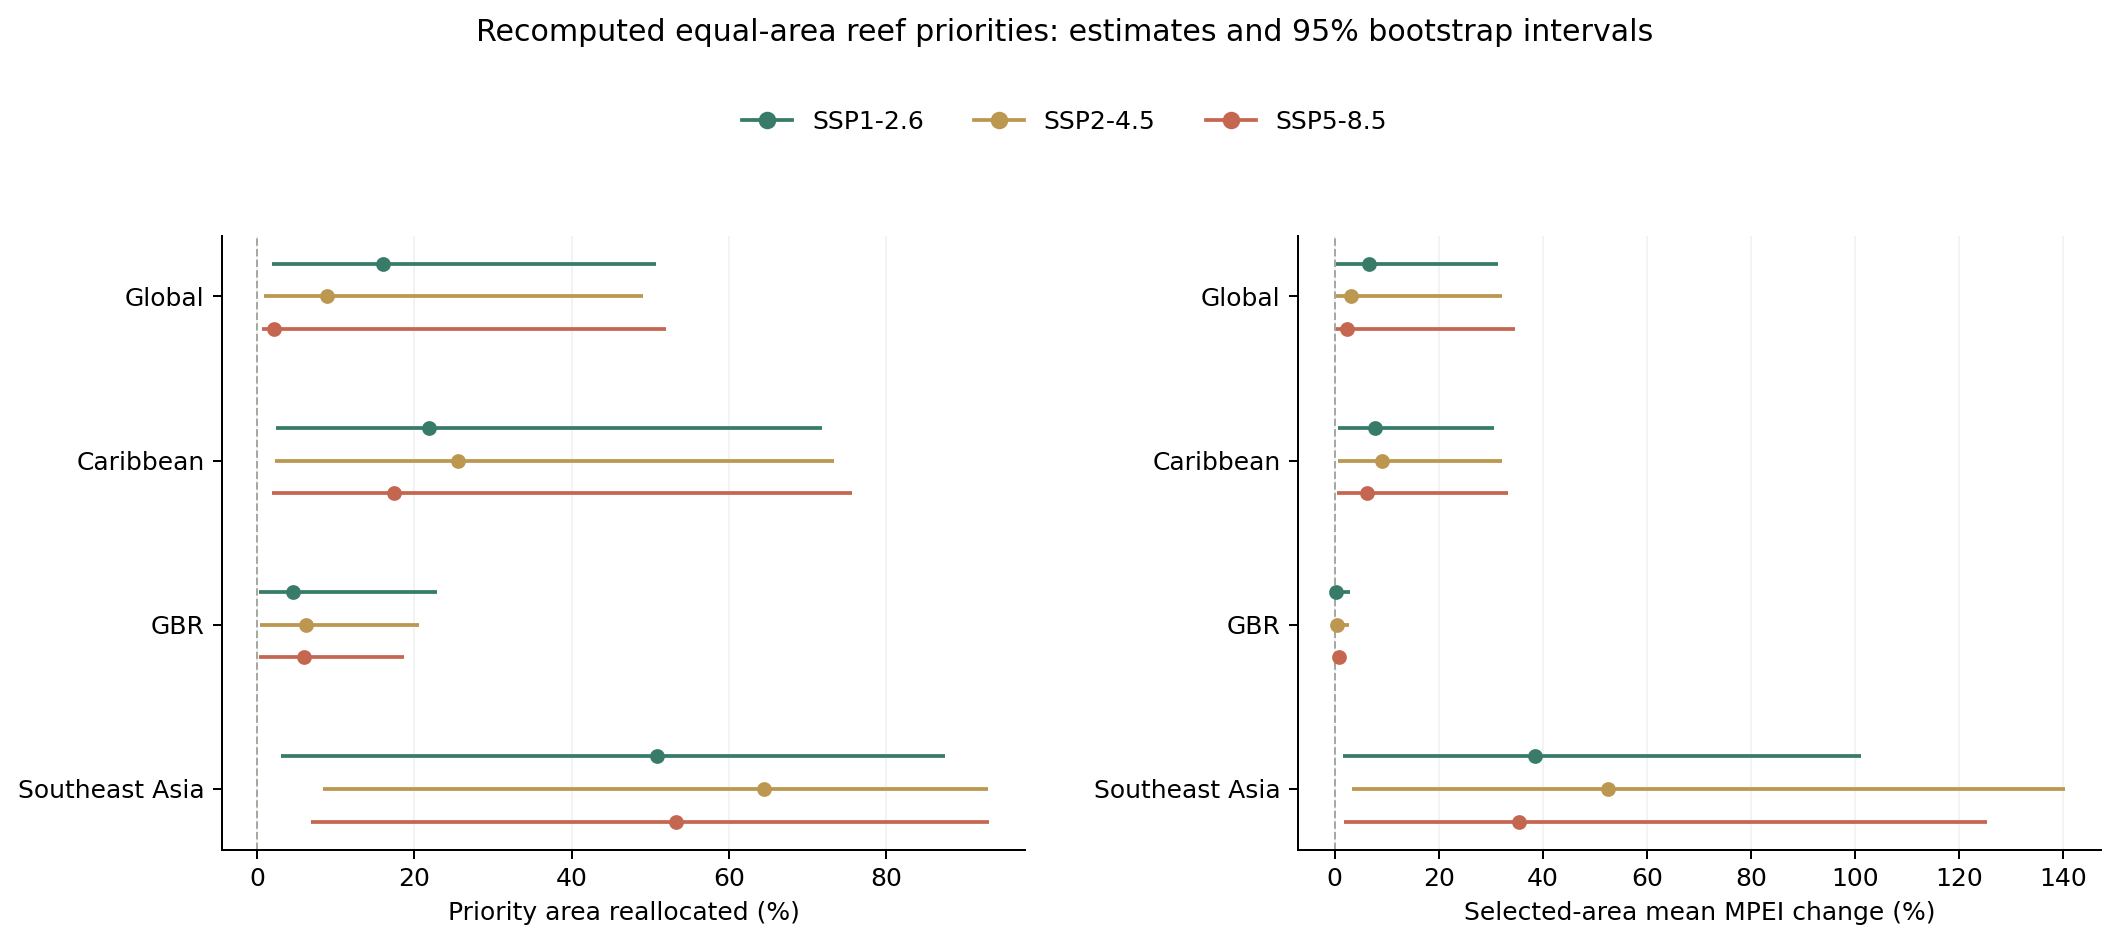

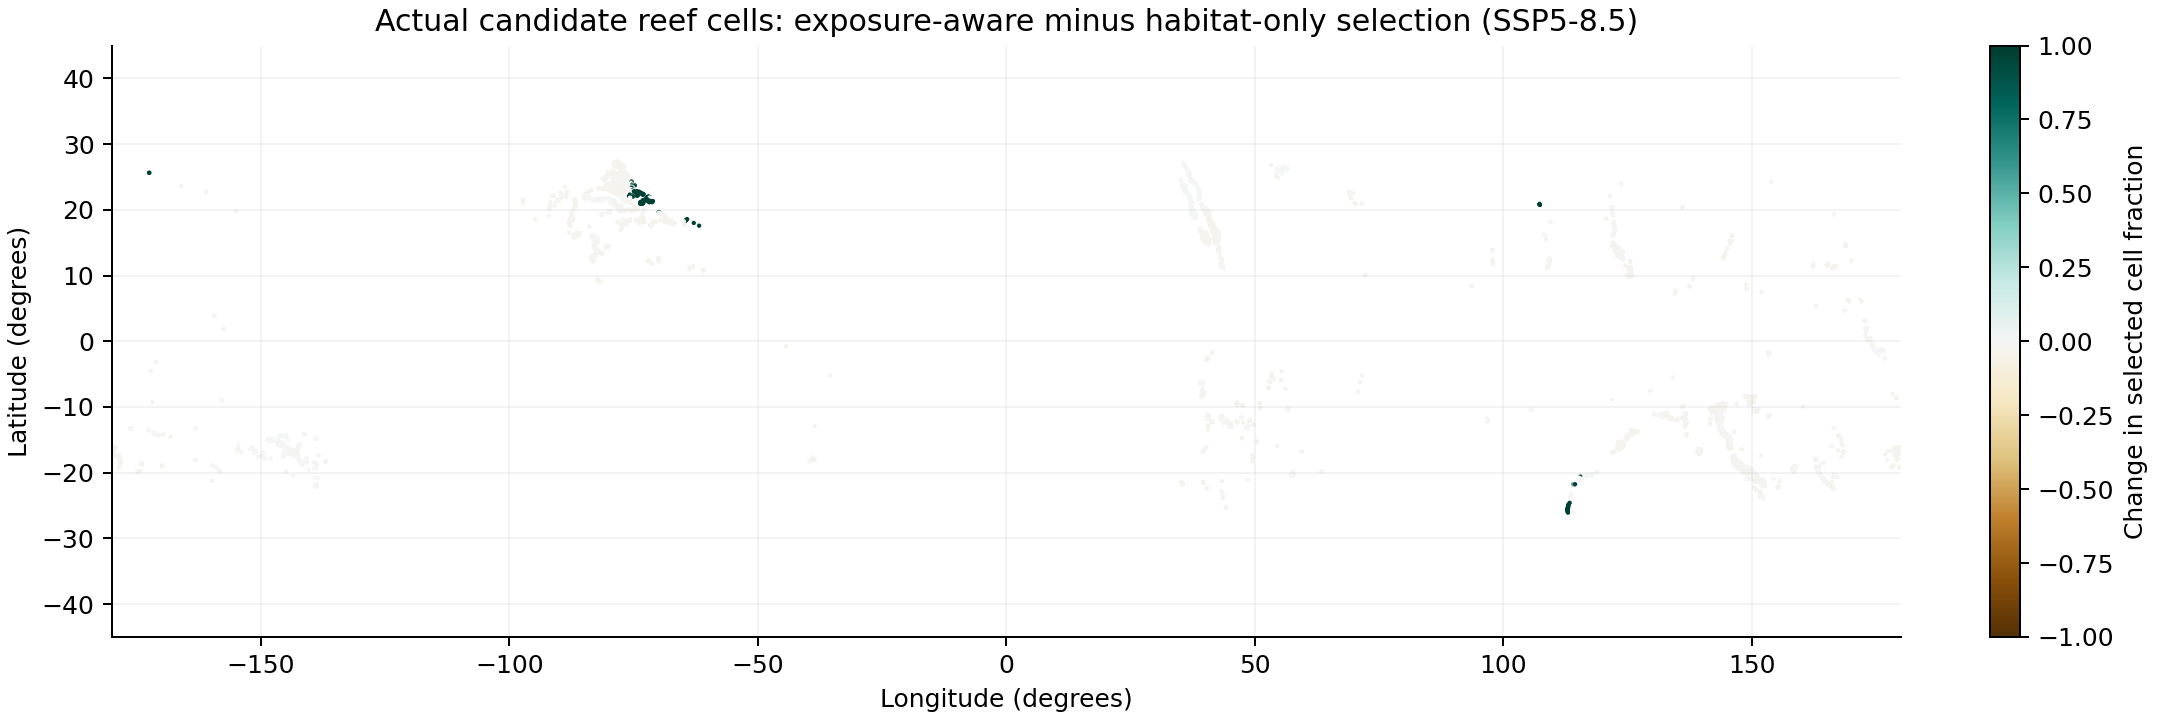

In [7]:
render_figures(table_s5, priorities, OUTPUT)
display(Image(filename=str(OUTPUT / "conservation_comparison.png")))
display(Image(filename=str(OUTPUT / "reef_priority_reallocation.png")))

## 8. 保存复现报告

成功报告只在前面的数据检查、计算、参考核对及绘图完成后保存。原始输入始终只读，Notebook的代码、表格、运行日志和图件一并保留，方便GitHub预览。

In [8]:
for record in manifest["files"]:
    if sha(ROOT / record["file"]) != record["sha256"]:
        raise ValueError(f"Source changed during execution: {record['file']}")
checks.update(status="passed", raw_inputs_modified=False,
              elapsed_seconds=round(time.perf_counter() - started, 3),
              environment={"python": platform.python_version(),
                           "numpy": np.__version__, "pandas": pd.__version__})
(OUTPUT / "run_checks.json").write_text(
    json.dumps(checks, ensure_ascii=False, indent=2) + "\n", encoding="utf-8")
display(pd.DataFrame([{
    "status": checks["status"], "actual_reef_cells": checks["input_rows"],
    "new_bootstrap_records": checks["draw_rows"], "full_frozen_design": checks["full_frozen_design"],
    "elapsed_seconds": checks["elapsed_seconds"]
}]))
print("Saved calculated outputs to outputs/notebook_demo/")

,status,actual_reef_cells,new_bootstrap_records,full_frozen_design,elapsed_seconds
0,passed,29746,12000,True,27.471


Saved calculated outputs to outputs/notebook_demo/


## 解读范围

此Notebook复现已归档派生网格输入到保护配置结果的模块。MPEI为外部模型暴露，不是生物内剂量或毒理效应。各SSP使用同一未来塑料场，情景差异来自栖息地支持。增加入选区域MPEI表示暴露优先级变化，不表示净化或保护实施成效。

原海洋模式、环境处理、MaxEnt训练及论文整体仍有其他输入和验证需求。详细数据字典见`data/README.md`，原计算函数及来源见`analysis/modules/conservation_demo/`。